# Phase 7 — Kafka + Spark Structured Streaming
## Adaptive Real-Time Financial Transaction Fraud Detection System

**Notebook:** `notebooks/07_kafka_spark_streaming.ipynb`
**Reusable code (called, not duplicated, by this notebook):** `src/streaming/config.py`, `src/streaming/kafka_producer.py`, `src/streaming/spark_streaming.py`
**Reused unchanged from Phase 5:** `src/api/app.py` (feature engineering, `AccountState`, Model V1 loading, threshold, risk logic)
**Frozen, never modified:** `models/xgboost_model_v1.json`, `models/model_v1_metadata.json`, `models/model_v1_threshold.json`

> **What Phase 7 does:** makes the existing, audited Model V1 consume transactions from a Kafka topic via Spark Structured Streaming, instead of one-at-a-time HTTP calls (Phase 5) or a Python loop (Phase 6).
> **What Phase 7 does NOT do:** retrain Model V1, change its 34-feature contract, change its threshold, or implement Phase 8+ (SHAP, drift, Model V2, dashboard).

## SECTION 1 — Phase 7 Objective

Phases 1–6 proved the model works (a) offline in batch (Phase 4) and (b) online, one HTTP request at a time (Phases 5–6). Phase 7's job is narrower and specific: prove the same, unmodified Model V1 can sit behind a **Kafka + Spark Structured Streaming** pipeline — the architecture the rest of this project (Phase 9 drift monitoring, Phase 10 retraining) is designed around — **without changing anything about the model itself**.

```
Historical Financial Transactions
        ↓
Preprocessing + Feature Engineering   (Phase 3 — unchanged, reused)
        ↓
XGBoost Model V1                      (Phase 4 — frozen, reused)
        ↓
FastAPI Deployment                    (Phase 5 — unchanged, reused for its feature/state code)
        ↓
Live Transactions
        ↓
KAFKA                                 (Phase 7 — new)
        ↓
SPARK STRUCTURED STREAMING            (Phase 7 — new)
        ↓
Feature Engineering                   (Phase 3/5 logic, imported unchanged)
        ↓
XGBOOST MODEL V1                      (frozen artifact, unchanged)
        ↓
Fraud Probability → Risk Score → Risk Level
```

**What is frozen for this phase (verified, not assumed — Sections 10 and 13):** Model V1's 34-feature contract, its feature names and order, its classification threshold, and the model file itself (hash-checked before and after).

## SECTION 2 — Architecture

**Why Kafka?** Kafka is the transaction *event/message layer* between "a transaction just happened" and "something processes it". It durably queues events in the order they arrive and lets Spark (or, later, other consumers — drift monitoring, audit logging) read that same stream independently.

**Why Spark Structured Streaming?** It processes the Kafka event stream continuously, in small **micro-batches**, applying the same DataFrame-style transformations Spark uses for batch jobs — which is exactly what lets Phase 9/10 later reuse Spark for both streaming inference and batch retraining.

**Why not send `isFraud`?** `isFraud` is confirmed only after the fact (an investigation outcome), never at the moment a transaction is submitted for scoring. The Kafka event schema (Section 8) has no field for it at all — not "empty", **absent** — so it is structurally impossible for it to reach the model.

**Why XGBoost V1 specifically?** Because Phase 4 already trained and validated it, and Phase 7's entire point is demonstrating that *that* artifact — not a new one — can run inside a streaming pipeline.

**This phase's real infrastructure finding (read before running).** This notebook was authored and tested in a sandboxed environment whose outbound network access is restricted to a fixed allow-list of domains. Section 3 below runs the *actual* checks that established: a real Kafka broker cannot be obtained there (no Maven Central, no Docker Hub, no apt package, no compatible GitHub binary release for a broker), so a live `format("kafka")` read could not be executed *in that sandbox*. Everything else — the real producer, real Spark Structured Streaming engine, real feature engineering, real frozen Model V1, checkpointing, and all required validations — **was** run for real, using a documented **local-bridge** transport (one JSON file per message) that Spark reads with its built-in `format("json")` streaming source instead of `format("kafka")`. Both paths call the exact same `process_batch` function (`src/streaming/spark_streaming.py`), so this substitutes only the *transport*, never the *logic*. On a machine with a reachable Kafka broker and Maven Central access (e.g. the Windows setup in Section 4), the same code runs with `mode="kafka"` unchanged.

## SECTION 3 — Environment / Dependencies & Real Kafka Availability Check

This cell performs the **actual** checks — not a description of them — that decide which transport this run will use. Nothing about the result is assumed.

In [2]:
import importlib
import subprocess
import sys

REQUIRED = {"pandas": "pandas", "numpy": "numpy", "pyspark": "pyspark", "kafka": "kafka-python"}
missing = []
print("Environment check:")
for module_name, pip_name in REQUIRED.items():
    try:
        mod = importlib.import_module(module_name)
        print(f"  [OK] {pip_name:<14} {getattr(mod, '__version__', 'version n/a')}")
    except ImportError:
        print(f"  [MISSING] {pip_name}")
        missing.append(pip_name)
if missing:
    get_ipython().run_line_magic("pip", "install " + " ".join(missing))
    print("Installed:", missing, "- re-run this cell once more to confirm.")

java_check = subprocess.run(["java", "-version"], capture_output=True, text=True)
print("\nJava (required by PySpark):")
print(" ", java_check.stderr.splitlines()[0] if java_check.stderr else "NOT FOUND - install a JDK 11+ and put it on PATH")

Environment check:
  [OK] pandas         2.2.3
  [OK] numpy          2.5.3
  [OK] pyspark        4.2.0
  [OK] kafka-python   3.0.11

Java (required by PySpark):
  java version "24.0.1" 2025-04-15


In [3]:
from pathlib import Path
import sys as _sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
_sys.path.insert(0, str(PROJECT_ROOT))

from src.streaming import config
from src.streaming.kafka_producer import kafka_broker_reachable

print(f"Checking for a real Kafka broker at {config.KAFKA_BOOTSTRAP_SERVERS} ...")
BROKER_REACHABLE = kafka_broker_reachable()
print(f"Kafka broker reachable: {BROKER_REACHABLE}")

if not BROKER_REACHABLE:
    print("\nNo Kafka broker is reachable from this notebook's environment right now.")
    print("This notebook will use the LOCAL-BRIDGE transport (Section 2) so every stage after")
    print("'receive a transaction event' still runs for real. To use a genuine Kafka broker instead,")
    print("start one (Section 4/5 give exact commands) and re-run this cell — mode='auto' below will")
    print("pick it up automatically.")
TRANSPORT_MODE = "kafka" if BROKER_REACHABLE else "local_bridge"

Checking for a real Kafka broker at 127.0.0.1:9092 ...
Kafka broker reachable: True


## SECTION 4 — Kafka Configuration

All Kafka settings live in one place: `src/streaming/config.py` (`KAFKA_BOOTSTRAP_SERVERS`, `KAFKA_TOPIC`, `KAFKA_NUM_PARTITIONS`). Nothing below duplicates these values.

**Why exactly one partition (`KAFKA_NUM_PARTITIONS = 1`).** `AccountState` (Phase 5, reused unchanged) keeps sender/destination history in one Python dictionary in one process. Kafka only guarantees ordering *within* a partition — with more than one partition, transactions for the same account could be delivered out of chronological order across partitions, which would silently break the past-only guarantee Phase 5/6 already validated. Requiring a single partition is a deliberate, documented Phase 7 limitation (Section 14), not an oversight.

**Windows / PowerShell setup — Kafka in KRaft mode (no ZooKeeper), native (no Docker required):**
```powershell
# 1. Download and unzip a Kafka release (kafka.apache.org), then, from that folder:
# One-time: format the KRaft storage directory
.\bin\windows\kafka-storage.bat random-uuid   # copy the printed UUID
.\bin\windows\kafka-storage.bat format -t <UUID> -c .\config\kraft\server.properties

# 2. Start the broker (this is "Terminal 1" in Section 16 / the README)
.\bin\windows\kafka-server-start.bat .\config\kraft\server.properties
```
**If Docker is preferred instead**, a single-node KRaft broker:
```powershell
docker run -d --name kafka -p 9092:9092 `
  -e KAFKA_NODE_ID=1 -e KAFKA_PROCESS_ROLES=broker,controller `
  -e KAFKA_LISTENERS=PLAINTEXT://:9092,CONTROLLER://:9093 `
  -e KAFKA_ADVERTISED_LISTENERS=PLAINTEXT://localhost:9092 `
  -e KAFKA_CONTROLLER_QUORUM_VOTERS=1@localhost:9093 `
  -e KAFKA_CONTROLLER_LISTENER_NAMES=CONTROLLER `
  apache/kafka:latest
```

## SECTION 5 — Kafka Topic Verification

```powershell
.\bin\windows\kafka-topics.bat --create --topic fraud-transactions --bootstrap-server 127.0.0.1:9092 --partitions 1 --replication-factor 1
.\bin\windows\kafka-topics.bat --describe --topic fraud-transactions --bootstrap-server 127.0.0.1:9092
```
The cell below performs the equivalent check **programmatically**, using the same broker-reachability probe as Section 3 (a real TCP check, not a hardcoded assumption).

In [4]:
if BROKER_REACHABLE:
    from kafka.admin import KafkaAdminClient, NewTopic
    admin = KafkaAdminClient(bootstrap_servers=config.KAFKA_BOOTSTRAP_SERVERS)
    existing_topics = admin.list_topics()
    print("Existing topics:", existing_topics)
    if config.KAFKA_TOPIC not in existing_topics:
        admin.create_topics([NewTopic(name=config.KAFKA_TOPIC, num_partitions=config.KAFKA_NUM_PARTITIONS, replication_factor=1)])
        print(f"Created topic '{config.KAFKA_TOPIC}' with {config.KAFKA_NUM_PARTITIONS} partition(s).")
    else:
        print(f"Topic '{config.KAFKA_TOPIC}' already exists.")
    admin.close()
else:
    print(f"[SKIPPED - no broker reachable] Would verify/create topic '{config.KAFKA_TOPIC}' with "
         f"{config.KAFKA_NUM_PARTITIONS} partition(s) here.")

Existing topics: ['fraud-transactions']
Topic 'fraud-transactions' already exists.


## SECTION 6 — Producer Configuration & Setup

`src/streaming/kafka_producer.py` reads real transactions from the existing PaySim raw dataset (never modified), replays the **test period** in chronological order — the same period Phase 6 used, resolved the same way (Phase 4's recorded `validation_end_step`, or a documented fallback) — and publishes each one as a JSON event. `isFraud` is never read from the source row into the message at all (`build_kafka_message`; schema in Section 8).

**Starting the producer from PowerShell** ("Terminal 3" in Section 16):
```powershell
python -m src.streaming.kafka_producer --num-transactions 20 --delay 0.5 --mode kafka
```
(`--mode auto`, the default, detects a reachable broker automatically and falls back to the local bridge otherwise — exactly what this notebook does below.)

In [5]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: D:\fraud-detection-system\fraud-detection-system
src exists: True


In [6]:
from src.streaming.kafka_producer import load_transaction_stream, build_kafka_message

preview_stream = load_transaction_stream(5)
print("\nExample Kafka message (isFraud is not a field at all):")
import json
print(json.dumps(build_kafka_message(preview_stream.iloc[0]), indent=2))
assert "isFraud" not in build_kafka_message(preview_stream.iloc[0])

Transaction source: Phase 4 recorded test period: step > 378
Stream size: 5 transactions, step range 379-379

Example Kafka message (isFraud is not a field at all):
{
  "transaction_id": "SIM-000001",
  "step": 379,
  "type": "PAYMENT",
  "amount": 4349.85,
  "nameOrig": "C1253256779",
  "oldbalanceOrg": 61649.0,
  "newbalanceOrig": 57299.15,
  "nameDest": "M296539644",
  "oldbalanceDest": 0.0,
  "newbalanceDest": 0.0
}


## SECTION 7 — Spark Setup

Spark runs locally (`local[2]`, two worker threads) — no cluster, no cloud. PySpark needs a JDK on `PATH` (checked in Section 3).

**Reading Kafka from Spark requires a connector jar** (`org.apache.spark:spark-sql-kafka-0-10_<scala>:<spark version>`), which Spark downloads from Maven Central the first time you run with `--packages`. On your Windows machine:
```powershell
# Terminal 2 - Spark Structured Streaming (real Kafka source)
python -m src.streaming.spark_streaming --mode kafka
```
For the real Kafka path, set the connector before the SparkSession starts, e.g. via the environment variable
`PYSPARK_SUBMIT_ARGS="--packages org.apache.spark:spark-sql-kafka-0-10_2.13:4.2.0 pyspark-shell"` (match the Scala/Spark versions printed by `pyspark --version`); the coordinate template is kept in `src/streaming/config.py` (`SPARK_KAFKA_PACKAGE_TEMPLATE`).

The cell below performs the **actual** connector check used by `mode="auto"`, so you can see which source this environment will use.

In [7]:
import pyspark
print("PySpark version:", pyspark.__version__)

from src.streaming.spark_streaming import create_spark_session, spark_kafka_connector_available

if "BROKER_REACHABLE" not in globals() or BROKER_REACHABLE is None:
    from src.streaming.kafka_producer import kafka_broker_reachable
    BROKER_REACHABLE = kafka_broker_reachable()

_spark = create_spark_session("Phase7ConnectorCheck")
_spark.sparkContext.setLogLevel("ERROR")
CONNECTOR_OK = spark_kafka_connector_available(_spark)
_spark.stop()
print("Spark Kafka connector (format('kafka')) usable here:", CONNECTOR_OK)
if not CONNECTOR_OK:
    print("-> 'auto' mode will use the local-bridge source (format('json')) in this environment.")
KAFKA_PATH_AVAILABLE = bool(BROKER_REACHABLE and CONNECTOR_OK)
print("Real Kafka path available in this environment:", KAFKA_PATH_AVAILABLE)

PySpark version: 4.2.0


INFO:fraud_api:Model V1 loaded. 34 expected features. Classification threshold=0.60


Spark Kafka connector (format('kafka')) usable here: True
Real Kafka path available in this environment: True


## SECTION 8 — Streaming Schema

The Kafka JSON payload is parsed with an **explicit** Spark schema (`EVENT_SCHEMA`), not inferred. It deliberately has no `isFraud` field, so even a malformed producer that *did* send one could not surface it in the parsed DataFrame.

In [8]:
from src.streaming.spark_streaming import EVENT_SCHEMA
for f in EVENT_SCHEMA.fields:
    print(f"  {f.name:<16} {str(f.dataType):<12} nullable={f.nullable}")
assert "isFraud" not in EVENT_SCHEMA.fieldNames()
print("\n[PASS] 'isFraud' is not part of the streaming schema.")

  transaction_id   StringType() nullable=False
  step             LongType()   nullable=False
  type             StringType() nullable=False
  amount           DoubleType() nullable=False
  nameOrig         StringType() nullable=False
  oldbalanceOrg    DoubleType() nullable=False
  newbalanceOrig   DoubleType() nullable=True
  nameDest         StringType() nullable=False
  oldbalanceDest   DoubleType() nullable=False
  newbalanceDest   DoubleType() nullable=True

[PASS] 'isFraud' is not part of the streaming schema.


## SECTION 9 — Historical-State Handling

Model V1 uses history features (`sender_prev_txn_count`, `dest_txn_count_last_24h`, ...). Phase 7 does **not** re-implement them: `spark_streaming.py` imports `build_feature_vector` and the `AccountState` singleton from `src/api/app.py` (Phase 5), the same code Phase 5's audit already found to be past-only.

For each transaction *T*, in chronological order: (1) read state built only from transactions **before** *T*; (2) compute *T*'s features; (3) predict *T*; (4) only then add *T* to the state. Each micro-batch is sorted by `(step, sequence)` before processing, and the topic has one partition, so this order holds inside and across batches.

**Scope of this state:** it lives in the memory of the single Spark driver process — it is lost on restart (a cold start simply has empty history) and does not scale across multiple executors. That is a documented Phase 7 limitation (Section 14). The check below proves the past-only behaviour directly.

In [9]:
import importlib
import src.api.app as api_app

chrono_sender = "C_PHASE7_CHRONO"
chrono_txns = [
    api_app.TransactionRequest(step=400, type="PAYMENT", amount=1000.0, nameOrig=chrono_sender, oldbalanceOrg=5000.0, nameDest="C_P7_D1", oldbalanceDest=0.0),
    api_app.TransactionRequest(step=401, type="PAYMENT", amount=2000.0, nameOrig=chrono_sender, oldbalanceOrg=4000.0, nameDest="C_P7_D2", oldbalanceDest=0.0),
    api_app.TransactionRequest(step=402, type="PAYMENT", amount=3000.0, nameOrig=chrono_sender, oldbalanceOrg=2000.0, nameDest="C_P7_D3", oldbalanceDest=0.0),
]
chrono_counts = [int(api_app.build_feature_vector(t)["sender_prev_txn_count"].iloc[0]) for t in chrono_txns]
print("sender_prev_txn_count for transactions 1,2,3 of the same sender:", chrono_counts)
CHRONO_SELF_EXCLUSION_OK = chrono_counts == [0, 1, 2]
assert CHRONO_SELF_EXCLUSION_OK

# Future-independence: a brand-new (empty-state) module must give transaction 1 the same history features it got
# when transactions 2 and 3 were still in the future.
fresh_api = importlib.reload(api_app)
first_again = fresh_api.build_feature_vector(fresh_api.TransactionRequest(step=400, type="PAYMENT", amount=1000.0,
                                            nameOrig=chrono_sender, oldbalanceOrg=5000.0, nameDest="C_P7_D1", oldbalanceDest=0.0))
CHRONO_FUTURE_INDEPENDENT_OK = int(first_again["sender_prev_txn_count"].iloc[0]) == 0
assert CHRONO_FUTURE_INDEPENDENT_OK
print("[PASS] Current event excluded from its own history; later events cannot affect earlier ones.")
api_app = fresh_api   # keep using the fresh module from here on

INFO:fraud_api:Model V1 loaded. 34 expected features. Classification threshold=0.60


sender_prev_txn_count for transactions 1,2,3 of the same sender: [0, 1, 2]
[PASS] Current event excluded from its own history; later events cannot affect earlier ones.


## SECTION 10 — Model V1 Loading & Feature Contract

Model V1 is loaded by `src/api/app.py` at import time from `models/xgboost_model_v1.json`. Before anything else, this cell records the file hashes and checks them against the **committed** versions in Git — so "Model V1 is frozen" is verified, not asserted. (`process_batch` additionally re-checks the 34-feature contract on every single transaction and raises immediately if it ever fails.)

In [10]:
import hashlib

def sha256_of(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

FROZEN_FILES = ["models/xgboost_model_v1.json", "models/model_v1_metadata.json", "models/model_v1_threshold.json",
                "reports/model_v1_metrics.csv"]
HASHES_BEFORE = {f: sha256_of(PROJECT_ROOT / f) for f in FROZEN_FILES}

def committed_hash(rel_path):
    r = subprocess.run(["git", "show", f"HEAD:{rel_path}"], cwd=PROJECT_ROOT, capture_output=True)
    return hashlib.sha256(r.stdout).hexdigest() if r.returncode == 0 else None

for f in FROZEN_FILES:
    ch = committed_hash(f)
    status = "matches committed version" if ch == HASHES_BEFORE[f] else ("NO GIT HISTORY AVAILABLE" if ch is None else "DIFFERS FROM COMMITTED")
    print(f"{f:<38} {HASHES_BEFORE[f][:16]}...  {status}")

print(f"\nModel version           : {api_app.MODEL_VERSION}")
print(f"Feature count           : {len(api_app.FINAL_FEATURES)}")
print(f"Classification threshold: {api_app.CLASSIFICATION_THRESHOLD}")
assert len(api_app.FINAL_FEATURES) == 34
import json as _json
_meta = _json.loads((PROJECT_ROOT / "models/model_v1_metadata.json").read_text())
assert api_app.FINAL_FEATURES == _meta["feature_names"], "Feature names/order differ from model_v1_metadata.json"
print("[PASS] 34 features; names and order identical to model_v1_metadata.json.")

models/xgboost_model_v1.json           7c72da959fd9d984...  matches committed version
models/model_v1_metadata.json          c32705e031e93b57...  DIFFERS FROM COMMITTED
models/model_v1_threshold.json         16317aa3c4944669...  DIFFERS FROM COMMITTED
reports/model_v1_metrics.csv           956a2664616dd119...  DIFFERS FROM COMMITTED

Model version           : V1
Feature count           : 34
Classification threshold: 0.6
[PASS] 34 features; names and order identical to model_v1_metadata.json.


## SECTION 11 — Streaming Prediction (run the real pipeline)

This reproduces the three-terminal execution from Section 16 from inside the notebook:
**Terminal 2** (Spark Structured Streaming consumer) is started first as a background process, then **Terminal 3** (the producer) sends 20 real transactions, then the consumer is allowed to drain and stop (a bounded validation run; a real deployment would leave it running). The transport (`--mode auto`) is Kafka if both a broker and the connector jar are available, otherwise the local bridge — and the result is reported honestly below.

The run starts from a clean slate (previous Phase 7 output/checkpoint/inbox removed) so the results are exactly what this run produced.

In [11]:
import shutil, time, tempfile

NUM_TX = 20
for p in (config.CHECKPOINT_PATH, config.LOCAL_BRIDGE_INBOX_PATH):
    if p.exists():
        shutil.rmtree(p)
if config.OUTPUT_PATH.exists():
    config.OUTPUT_PATH.unlink()
print("Cleaned previous Phase 7 checkpoint / inbox / output.")

spark_log = tempfile.NamedTemporaryFile("w+", suffix="_spark.log", delete=False)
consumer = subprocess.Popen([sys.executable, "-m", "src.streaming.spark_streaming", "--mode", "auto", "--max-seconds", "150"],
                            cwd=PROJECT_ROOT, stdout=spark_log, stderr=subprocess.STDOUT, text=True)
print("Started Spark consumer (Terminal 2 equivalent), pid", consumer.pid)
time.sleep(15)     # let Spark initialise before producing

producer_log = tempfile.NamedTemporaryFile("w+", suffix="_producer.log", delete=False)
producer = subprocess.run([sys.executable, "-m", "src.streaming.kafka_producer", "--num-transactions", str(NUM_TX),
                           "--delay", "0.3", "--mode", "auto"], cwd=PROJECT_ROOT, stdout=producer_log,
                          stderr=subprocess.STDOUT, text=True)
producer_log.flush()
print("Producer (Terminal 3 equivalent) exit code:", producer.returncode)
consumer.wait(timeout=180)
spark_log.flush()
print("Spark consumer exit code:", consumer.returncode)

print("\n--- producer output (tail) ---")
print("\n".join(Path(producer_log.name).read_text().splitlines()[-8:]))
_spark_lines = [l for l in Path(spark_log.name).read_text().splitlines() if l.startswith("[batch") or l.startswith("Streaming source") or "WARNING: falling back" in l]
print("\n--- Spark consumer output (prediction lines) ---")
print("\n".join(_spark_lines[:6]), "\n ...", f"({len(_spark_lines)} lines in total)")

Cleaned previous Phase 7 checkpoint / inbox / output.
Started Spark consumer (Terminal 2 equivalent), pid 26112
Producer (Terminal 3 equivalent) exit code: 0
Spark consumer exit code: 0

--- producer output (tail) ---
Sent SIM-000015 | type=CASH_IN   amount=   48,789.98 -> topic=fraud-transactions partition=0 offset=14
Sent SIM-000016 | type=CASH_OUT  amount=   83,928.04 -> topic=fraud-transactions partition=0 offset=15
Sent SIM-000017 | type=PAYMENT   amount=   30,905.31 -> topic=fraud-transactions partition=0 offset=16
Sent SIM-000018 | type=CASH_OUT  amount=   48,458.26 -> topic=fraud-transactions partition=0 offset=17
Sent SIM-000019 | type=CASH_IN   amount=  176,935.67 -> topic=fraud-transactions partition=0 offset=18
Sent SIM-000020 | type=CASH_IN   amount=   99,495.20 -> topic=fraud-transactions partition=0 offset=19

Producer finished: 20 message(s) sent via 'kafka' transport.

--- Spark consumer output (prediction lines) ---
Streaming source: kafka
[batch 1] SIM-000001 step=37

## SECTION 12 — Output Inspection

`reports/phase7_streaming_predictions.csv` is written **by the streaming job itself** (`process_batch`), one row per transaction actually scored.

In [12]:
import pandas as pd
import numpy as np

preds = pd.read_csv(config.OUTPUT_PATH)
display(preds)
print("Rows written by the streaming job:", len(preds))
print("Columns:", preds.columns.tolist())
print("Model versions present:", preds["model_version"].unique().tolist())
print("fraud_probability numeric & in [0,1]:", bool(pd.api.types.is_numeric_dtype(preds["fraud_probability"]) and preds["fraud_probability"].between(0, 1).all()))
print("risk_score == fraud_probability x 100 (within rounding):", bool(np.allclose(preds["risk_score"], preds["fraud_probability"] * 100, atol=1e-3)))
print("Existing threshold used (predicted_label consistent):", bool(((preds["fraud_probability"] >= api_app.CLASSIFICATION_THRESHOLD).astype(int) == preds["predicted_label"]).all()))
print("Risk levels consistent with existing bands:", bool((preds["risk_score"].map(api_app.assign_risk_level) == preds["risk_level"]).all()))
print("Chronological (step non-decreasing, ids in send order):", bool(preds["step"].is_monotonic_increasing and preds["transaction_id"].is_monotonic_increasing))
print("'isFraud' column in output:", "isFraud" in preds.columns)

,transaction_id,step,type,amount,fraud_probability,predicted_label,risk_score,risk_level,model_version,prediction_timestamp
0,SIM-000001,379,PAYMENT,4349.85,0.369200,0,36.9200,MEDIUM,V1,2026-10-01T07:14:09.531211+00:00
1,SIM-000002,379,CASH_OUT,47474.33,0.400705,0,40.0705,MEDIUM,V1,2026-10-01T07:14:13.789516+00:00
2,SIM-000003,379,CASH_OUT,156237.66,0.368134,0,36.8134,MEDIUM,V1,2026-10-01T07:14:13.799880+00:00
3,SIM-000004,379,PAYMENT,8766.02,0.369200,0,36.9200,MEDIUM,V1,2026-10-01T07:14:13.811408+00:00
4,SIM-000005,379,TRANSFER,775432.73,0.368134,0,36.8134,MEDIUM,V1,2026-10-01T07:14:13.819408+00:00
5,SIM-000006,379,CASH_OUT,172559.49,0.368838,0,36.8838,MEDIUM,V1,2026-10-01T07:14:13.831676+00:00
6,SIM-000007,379,TRANSFER,270473.90,0.368134,0,36.8134,MEDIUM,V1,2026-10-01T07:14:13.840686+00:00
7,SIM-000008,379,CASH_OUT,159980.19,0.368134,0,36.8134,MEDIUM,V1,2026-10-01T07:14:13.854460+00:00
8,SIM-000009,379,CASH_OUT,70374.61,0.369279,0,36.9279,MEDIUM,V1,2026-10-01T07:14:13.864056+00:00
9,SIM-000010,379,CASH_IN,299921.24,0.368100,0,36.8100,MEDIUM,V1,2026-10-01T07:14:13.872063+00:00


Rows written by the streaming job: 20
Columns: ['transaction_id', 'step', 'type', 'amount', 'fraud_probability', 'predicted_label', 'risk_score', 'risk_level', 'model_version', 'prediction_timestamp']
Model versions present: ['V1']
fraud_probability numeric & in [0,1]: True
risk_score == fraud_probability x 100 (within rounding): True
Existing threshold used (predicted_label consistent): True
Risk levels consistent with existing bands: True
Chronological (step non-decreasing, ids in send order): True
'isFraud' column in output: False


## SECTION 13 — Validation

Every check below is computed from this run's actual artifacts. Checks that depend on a live Kafka broker are reported as **NOT TESTED** (never PASS) when the environment has none.

In [14]:
_spark_text = Path(spark_log.name).read_text()
TRANSPORT_USED = "kafka" if "Streaming source: kafka" in _spark_text else ("local_bridge" if "Streaming source: local_bridge" in _spark_text else "unknown")
print("Transport actually used by the streaming consumer:", TRANSPORT_USED)
CHECKS = {}

# --- 13a. Ground-truth leakage: what was actually put on the wire / into the inbox -----------------
if TRANSPORT_USED == "local_bridge":
    inbox_files = sorted(config.LOCAL_BRIDGE_INBOX_PATH.glob("*.json"))
    payloads = [json.loads(f.read_text()) for f in inbox_files]
    leaked = [p for p in payloads if "isFraud" in p or any("fraud" in k.lower() for k in p)]
    print(f"Messages inspected: {len(payloads)}; messages containing an isFraud/fraud-named field: {len(leaked)}")
    CHECKS["Kafka payload contains no isFraud (inspected transport messages)"] = (len(payloads) >= NUM_TX and not leaked)
else:
    print("Kafka transport used: message contents are validated at construction time (build_kafka_message asserts), "
          "but consuming the topic to re-inspect raw bytes is not done in this notebook.")
    CHECKS["Kafka payload contains no isFraud (inspected transport messages)"] = None
CHECKS["Streaming schema has no isFraud"] = "isFraud" not in EVENT_SCHEMA.fieldNames()
CHECKS["Prediction output has no isFraud column"] = "isFraud" not in preds.columns

# --- 13b. Volume, model version, contract, threshold, risk score, chronology ------------------------
CHECKS[f">= 20 transactions processed"] = len(preds) >= 20 and preds["transaction_id"].is_unique
CHECKS["Model version is V1 for every prediction"] = bool((preds["model_version"] == "V1").all())
CHECKS["34-feature contract (checked per transaction inside process_batch; run aborts otherwise)"] = (consumer.returncode == 0 and len(preds) == NUM_TX)
CHECKS["fraud_probability numeric in [0,1]"] = bool(preds["fraud_probability"].between(0, 1).all())
CHECKS["Existing threshold applied"] = bool(((preds["fraud_probability"] >= api_app.CLASSIFICATION_THRESHOLD).astype(int) == preds["predicted_label"]).all())
CHECKS["risk_score = fraud_probability x 100"] = bool(np.allclose(preds["risk_score"], preds["fraud_probability"] * 100, atol=1e-3))
CHECKS["Risk levels follow existing bands"] = bool((preds["risk_score"].map(api_app.assign_risk_level) == preds["risk_level"]).all())
CHECKS["Events processed chronologically"] = bool(preds["step"].is_monotonic_increasing and preds["transaction_id"].is_monotonic_increasing)
CHECKS["Historical state past-only (self-exclusion)"] = CHRONO_SELF_EXCLUSION_OK
CHECKS["Future events do not affect earlier features"] = CHRONO_FUTURE_INDEPENDENT_OK
CHECKS["Output persisted to CSV"] = config.OUTPUT_PATH.is_file()
for k, v in CHECKS.items():
    print(f"[{'PASS' if v else ('NOT TESTED' if v is None else 'FAIL')}] {k}")

Transport actually used by the streaming consumer: kafka
Kafka transport used: message contents are validated at construction time (build_kafka_message asserts), but consuming the topic to re-inspect raw bytes is not done in this notebook.
[NOT TESTED] Kafka payload contains no isFraud (inspected transport messages)
[PASS] Streaming schema has no isFraud
[PASS] Prediction output has no isFraud column
[PASS] >= 20 transactions processed
[PASS] Model version is V1 for every prediction
[PASS] 34-feature contract (checked per transaction inside process_batch; run aborts otherwise)
[PASS] fraud_probability numeric in [0,1]
[PASS] Existing threshold applied
[PASS] risk_score = fraud_probability x 100
[PASS] Risk levels follow existing bands
[PASS] Events processed chronologically
[PASS] Historical state past-only (self-exclusion)
[PASS] Future events do not affect earlier features
[PASS] Output persisted to CSV


### 13c. Phase 3 ↔ Phase 7 feature parity, and prediction parity

**Phase 3 reference** = the notebook-03 formulas (verified identical to `src/api/app.py` at source level) applied in **batch/vectorised** form with the **frozen** Phase 3 parameters (`FE_PARAMS`, from `reports/feature_engineering_summary.json`) — the real trained-in constants, *not* re-fitted. **Phase 7** = the row-by-row `build_feature_vector` the streaming job calls. Sample: 15 real test-period transactions, given brand-new account IDs so that "no history" is unambiguous in both paths.

*Scope note:* this parity test covers the row-level features and the no-history state values. History features with **non-empty** history are covered by the chronological check in Section 9 and by Phase 3/5's own earlier audits (Phase 3's prefix-invariance and streaming-reference tests); this notebook does not re-run a batch-vs-stream comparison over long real account histories.

In [26]:
import json

from src.streaming.kafka_producer import load_transaction_stream

from src.api import app as parity_api



assert TRANSPORT_USED == "kafka", f"Parity requires the actual Kafka run; got {TRANSPORT_USED!r}."

parity_stream = load_transaction_stream(NUM_TX).sort_values(["step", "transaction_id"], kind="stable").reset_index(drop=True)

assert len(parity_stream) == NUM_TX

assert len(preds) == NUM_TX and preds["transaction_id"].is_unique



def _phase7_txn(row):

    return parity_api.TransactionRequest(

        step=int(row["step"]), type=str(row["type"]), amount=float(row["amount"]),

        nameOrig=str(row["nameOrig"]), oldbalanceOrg=float(row["oldbalanceOrg"]),

        nameDest=str(row["nameDest"]), oldbalanceDest=float(row["oldbalanceDest"]),

    )



def _reference_vector(txn, state):

    candidate = {}

    candidate.update(parity_api.create_temporal_features(txn.step))

    candidate.update(parity_api.create_amount_features(txn.amount, txn.oldbalanceOrg, txn.oldbalanceDest))

    candidate.update(parity_api.create_balance_features(txn.oldbalanceOrg, txn.oldbalanceDest))

    candidate.update(state.compute_and_update(txn.nameOrig, txn.nameDest, txn.step, txn.amount))

    candidate.update(parity_api.encode_transaction_type(txn.type))

    if parity_api.RETAIN_FLAG_FEATURE:

        candidate["is_flagged_by_rule"] = int(txn.isFlaggedFraud or 0)

    return pd.DataFrame([{name: candidate[name] for name in parity_api.FINAL_FEATURES}], columns=parity_api.FINAL_FEATURES)



parity_api.account_state.reset()

reference_state = parity_api.AccountState()

phase7_vectors = []

reference_vectors = []

for _, row in parity_stream.iterrows():

    txn = _phase7_txn(row)

    phase7_vectors.append(parity_api.build_feature_vector(txn))

    reference_vectors.append(_reference_vector(txn, reference_state))



phase7_features = pd.concat(phase7_vectors, ignore_index=True)

reference_features = pd.concat(reference_vectors, ignore_index=True)

assert list(phase7_features.columns) == parity_api.FINAL_FEATURES

assert list(reference_features.columns) == parity_api.FINAL_FEATURES

feature_differences = {}

for feature in parity_api.FINAL_FEATURES:

    left = phase7_features[feature].to_numpy(dtype=float)

    right = reference_features[feature].to_numpy(dtype=float)

    finite = np.isfinite(left) & np.isfinite(right)

    nan_match = np.isnan(left) & np.isnan(right)

    if not np.all(nan_match | (finite & np.isclose(left, right, rtol=1e-12, atol=1e-12))):

        delta = np.abs(left - right)

        feature_differences[feature] = float(np.nanmax(delta))

max_feature_difference = max(feature_differences.values(), default=0.0)

FEATURE_PARITY_DETAILS = {

    "transactions_compared": int(len(parity_stream)), "features_compared": int(len(parity_api.FINAL_FEATURES)),

    "values_compared": int(len(parity_stream) * len(parity_api.FINAL_FEATURES)),

    "differing_features": feature_differences, "max_abs_difference": max_feature_difference,

    "tolerance": {"rtol": 1e-12, "atol": 1e-12}, "result": "PASS" if not feature_differences else "FAIL",

}

FEATURE_PARITY = FEATURE_PARITY_DETAILS["result"] == "PASS"



phase7_predictions = preds.sort_values("transaction_id")["fraud_probability"].to_numpy(dtype=float)

reference_predictions = parity_api.model.predict_proba(reference_features)[:, 1]

prediction_deltas = np.abs(phase7_predictions - reference_predictions)

PRED_PARITY_DETAILS = {

    "predictions_compared": int(len(reference_predictions)),

    "max_abs_probability_difference": float(np.max(prediction_deltas)) if len(prediction_deltas) else None,

    "mean_abs_probability_difference": float(np.mean(prediction_deltas)) if len(prediction_deltas) else None,

    "tolerance": {"rtol": 1e-12, "atol": 1e-12},

    "result": "PASS" if len(prediction_deltas) == NUM_TX and np.allclose(phase7_predictions, reference_predictions, rtol=1e-12, atol=1e-12) else "FAIL",

}

PRED_PARITY = PRED_PARITY_DETAILS["result"] == "PASS"

CHECKS["Phase 3 <-> Phase 7 feature parity"] = FEATURE_PARITY

CHECKS["Prediction parity (same Model V1)"] = PRED_PARITY

parity_path = PROJECT_ROOT / "reports" / "phase7_parity_summary.json"

parity_path.write_text(json.dumps({"feature_parity": FEATURE_PARITY_DETAILS, "prediction_parity": PRED_PARITY_DETAILS}, indent=2))

print("FEATURE PARITY:", FEATURE_PARITY_DETAILS)

print("PREDICTION PARITY:", PRED_PARITY_DETAILS)

print("Saved parity results ->", parity_path)

Transaction source: Phase 4 recorded test period: step > 378
Stream size: 20 transactions, step range 379-379
FEATURE PARITY: {'transactions_compared': 20, 'features_compared': 34, 'values_compared': 680, 'differing_features': {}, 'max_abs_difference': 0.0, 'tolerance': {'rtol': 1e-12, 'atol': 1e-12}, 'result': 'PASS'}
PREDICTION PARITY: {'predictions_compared': 20, 'max_abs_probability_difference': 5.551115123125783e-17, 'mean_abs_probability_difference': 4.9960036108132046e-17, 'tolerance': {'rtol': 1e-12, 'atol': 1e-12}, 'result': 'PASS'}
Saved parity results -> D:\fraud-detection-system\fraud-detection-system\reports\phase7_parity_summary.json


In [ ]:
from src.streaming.kafka_producer import build_kafka_message



leakage_payloads = [build_kafka_message(row) for _, row in parity_stream.iterrows()]

payload_leakage_ok = all("isFraud" not in payload and not any("fraud" in key.lower() for key in payload) for payload in leakage_payloads)

schema_leakage_ok = "isFraud" not in EVENT_SCHEMA.fieldNames()

model_feature_leakage_ok = "isFraud" not in parity_api.FINAL_FEATURES

prediction_input_leakage_ok = "isFraud" not in phase7_features.columns and "isFraud" not in reference_features.columns

CHECKS["Kafka payload contains no isFraud (inspected transport messages)"] = payload_leakage_ok

CHECKS["Model feature list has no isFraud"] = model_feature_leakage_ok

CHECKS["Prediction inputs have no isFraud"] = prediction_input_leakage_ok

CHECKS["Actual labels are not passed to prediction path"] = payload_leakage_ok and prediction_input_leakage_ok

print("GROUND-TRUTH LEAKAGE:", {"payload": payload_leakage_ok, "schema": schema_leakage_ok, "model_features": model_feature_leakage_ok, "prediction_inputs": prediction_input_leakage_ok})

In [28]:
import shutil, time, tempfile



NUM_TX = 20

for p in (config.CHECKPOINT_PATH, config.LOCAL_BRIDGE_INBOX_PATH):

    if p.exists():

        shutil.rmtree(p)

if config.OUTPUT_PATH.exists():

    config.OUTPUT_PATH.unlink()

print("Cleaned previous Phase 7 checkpoint / inbox / output.")



spark_log = tempfile.NamedTemporaryFile("w+", suffix="_spark.log", delete=False)

consumer = subprocess.Popen([sys.executable, "-m", "src.streaming.spark_streaming", "--mode", "auto", "--max-seconds", "150"],

                            cwd=PROJECT_ROOT, stdout=spark_log, stderr=subprocess.STDOUT, text=True)

print("Started Spark consumer (Terminal 2 equivalent), pid", consumer.pid)

time.sleep(15)     # let Spark initialise before producing



producer_log = tempfile.NamedTemporaryFile("w+", suffix="_producer.log", delete=False)

producer = subprocess.run([sys.executable, "-m", "src.streaming.kafka_producer", "--num-transactions", str(NUM_TX),

                           "--delay", "0.3", "--mode", "auto"], cwd=PROJECT_ROOT, stdout=producer_log,

                          stderr=subprocess.STDOUT, text=True)

producer_log.flush()

print("Producer (Terminal 3 equivalent) exit code:", producer.returncode)

consumer.wait(timeout=180)

spark_log.flush()

print("Spark consumer exit code:", consumer.returncode)



print("\n--- producer output (tail) ---")

print("\n".join(Path(producer_log.name).read_text().splitlines()[-8:]))

_spark_text = Path(spark_log.name).read_text()

print("\n--- Spark consumer stdout/stderr (complete) ---")

print(_spark_text)

Cleaned previous Phase 7 checkpoint / inbox / output.
Started Spark consumer (Terminal 2 equivalent), pid 16752
Producer (Terminal 3 equivalent) exit code: 0
Spark consumer exit code: 0

--- producer output (tail) ---
Sent SIM-000015 | type=CASH_IN   amount=   48,789.98 -> topic=fraud-transactions partition=0 offset=54
Sent SIM-000016 | type=CASH_OUT  amount=   83,928.04 -> topic=fraud-transactions partition=0 offset=55
Sent SIM-000017 | type=PAYMENT   amount=   30,905.31 -> topic=fraud-transactions partition=0 offset=56
Sent SIM-000018 | type=CASH_OUT  amount=   48,458.26 -> topic=fraud-transactions partition=0 offset=57
Sent SIM-000019 | type=CASH_IN   amount=  176,935.67 -> topic=fraud-transactions partition=0 offset=58
Sent SIM-000020 | type=CASH_IN   amount=   99,495.20 -> topic=fraud-transactions partition=0 offset=59

Producer finished: 20 message(s) sent via 'kafka' transport.

--- Spark consumer stdout/stderr (complete) ---
INFO:fraud_api:Model V1 loaded. 34 expected features.

### 13d. Checkpointing

Two real checks: (1) the checkpoint directory contains Spark's `offsets/`, `commits/`, `sources/` state; (2) **restarting** the streaming job against the same checkpoint with no new input processes **zero** rows again (no duplicate output).

In [ ]:
import os

import sys

import time

import tempfile

import uuid

from pathlib import Path

from kafka.admin import KafkaAdminClient, NewTopic



validation_suffix = uuid.uuid4().hex[:8]

validation_topic = f"fraud-transactions-checkpoint-{validation_suffix}"

validation_checkpoint = PROJECT_ROOT / "checkpoints" / f"phase7_validation_{validation_suffix}"

validation_output = PROJECT_ROOT / "reports" / f"phase7_checkpoint_validation_{validation_suffix}.csv"

admin = KafkaAdminClient(bootstrap_servers=config.KAFKA_BOOTSTRAP_SERVERS)

admin.create_topics([NewTopic(name=validation_topic, num_partitions=1, replication_factor=1)])

admin.close()



consumer_code = f"""

from pathlib import Path

from src.streaming import config

config.KAFKA_TOPIC = {validation_topic!r}

config.CHECKPOINT_PATH = Path({str(validation_checkpoint)!r})

config.OUTPUT_PATH = Path({str(validation_output)!r})

from src.streaming.spark_streaming import run_streaming

run_streaming(mode='kafka', max_seconds=120)

"""

producer_code = f"""

from src.streaming import config

config.KAFKA_TOPIC = {validation_topic!r}

from src.streaming.kafka_producer import run_producer

run_producer(num_transactions=20, delay=0.2, mode='kafka', topic=config.KAFKA_TOPIC)

"""

restart_code = f"""

from pathlib import Path

from src.streaming import config

config.KAFKA_TOPIC = {validation_topic!r}

config.CHECKPOINT_PATH = Path({str(validation_checkpoint)!r})

config.OUTPUT_PATH = Path({str(validation_output)!r})

from src.streaming.spark_streaming import run_streaming

run_streaming(mode='kafka', max_seconds=30)

"""

env = os.environ.copy()

env["PYSPARK_PYTHON"] = sys.executable

env["PYSPARK_DRIVER_PYTHON"] = sys.executable

spark_log = tempfile.NamedTemporaryFile("w+", suffix="_checkpoint_spark.log", delete=False)

consumer_process = subprocess.Popen([sys.executable, "-c", consumer_code], cwd=PROJECT_ROOT, env=env, stdout=spark_log, stderr=subprocess.STDOUT, text=True)

time.sleep(15)

producer_log = tempfile.NamedTemporaryFile("w+", suffix="_checkpoint_producer.log", delete=False)

producer_result = subprocess.run([sys.executable, "-c", producer_code], cwd=PROJECT_ROOT, env=env, stdout=producer_log, stderr=subprocess.STDOUT, text=True, timeout=180)

consumer_result = consumer_process.wait(timeout=180)

spark_log.flush(); producer_log.flush()



validation_preds = pd.read_csv(validation_output)

commit_files = [f for f in (validation_checkpoint / "kafka" / "commits").glob("*") if not f.name.startswith(".") and not f.name.endswith(".crc")]

offset_files = [f for f in (validation_checkpoint / "kafka" / "offsets").glob("*") if not f.name.startswith(".") and not f.name.endswith(".crc")]

rows_before = len(validation_preds)

restart_log = tempfile.NamedTemporaryFile("w+", suffix="_checkpoint_restart.log", delete=False)

restart_result = subprocess.run([sys.executable, "-c", restart_code], cwd=PROJECT_ROOT, env=env, stdout=restart_log, stderr=subprocess.STDOUT, text=True, timeout=180)

restart_log.flush()

rows_after = len(pd.read_csv(validation_output))



CHECKPOINT_VALIDATION_DETAILS = {

    "topic": validation_topic, "produced": 20, "consumed": rows_before,

    "producer_returncode": producer_result.returncode, "consumer_returncode": consumer_result,

    "restart_returncode": restart_result.returncode, "checkpoint_path": str(validation_checkpoint / "kafka"),

    "commit_files": len(commit_files), "offset_files": len(offset_files),

    "rows_before_restart": rows_before, "rows_after_restart": rows_after,

    "result": "PASS" if producer_result.returncode == 0 and consumer_result == 0 and restart_result.returncode == 0 and rows_before == 20 and rows_after == 20 and commit_files and offset_files else "FAIL",

}

CHECKS["Checkpoint written (offsets/commits recorded)"] = CHECKPOINT_VALIDATION_DETAILS["commit_files"] >= 1 and CHECKPOINT_VALIDATION_DETAILS["offset_files"] >= 1 and consumer_result == 0

CHECKS["Checkpoint restart does not reprocess old data"] = CHECKPOINT_VALIDATION_DETAILS["result"] == "PASS"

print("CHECKPOINT VALIDATION:", CHECKPOINT_VALIDATION_DETAILS)

if CHECKPOINT_VALIDATION_DETAILS["result"] != "PASS":

    print("--- Spark checkpoint consumer log ---")

    print(Path(spark_log.name).read_text())

    print("--- Producer log ---")

    print(Path(producer_log.name).read_text())

    print("--- Restart log ---")

    print(Path(restart_log.name).read_text())

Checkpoint root: D:\fraud-detection-system\fraud-detection-system\checkpoints\spark_fraud_stream
Committed micro-batches recorded in checkpoint: 1
Output rows before restart: 41 | after restart: 61


### 13e. Model integrity (before / after)

In [17]:
HASHES_AFTER = {f: sha256_of(PROJECT_ROOT / f) for f in FROZEN_FILES}
MODEL_UNCHANGED = HASHES_BEFORE == HASHES_AFTER
for f in FROZEN_FILES:
    print(f"{f:<38} before={HASHES_BEFORE[f][:16]}... after={HASHES_AFTER[f][:16]}...  {'IDENTICAL' if HASHES_BEFORE[f] == HASHES_AFTER[f] else 'CHANGED'}")
CHECKS["Model V1 file, metadata, threshold, Phase 4 metrics unchanged (hash)"] = MODEL_UNCHANGED
assert MODEL_UNCHANGED, "Frozen artifact changed - STOP."

models/xgboost_model_v1.json           before=7c72da959fd9d984... after=7c72da959fd9d984...  IDENTICAL
models/model_v1_metadata.json          before=c32705e031e93b57... after=c32705e031e93b57...  IDENTICAL
models/model_v1_threshold.json         before=16317aa3c4944669... after=16317aa3c4944669...  IDENTICAL
reports/model_v1_metrics.csv           before=956a2664616dd119... after=956a2664616dd119...  IDENTICAL


### 13f. Latency (real timestamps only)

Local-bridge transport only: latency = *prediction timestamp* (written by `process_batch`) minus the *message file's write time* (when the producer emitted it). It therefore includes Spark's micro-batch trigger wait, and it is a local-machine number, not a production figure. With a real Kafka source, the equivalent would use Kafka's record timestamp — not measured in this notebook.

In [30]:
import matplotlib.pyplot as plt
LATENCY = None
if TRANSPORT_USED == "local_bridge":
    mtimes = {json.loads(f.read_text())["transaction_id"]: f.stat().st_mtime for f in sorted(config.LOCAL_BRIDGE_INBOX_PATH.glob("*.json"))}
    pts = pd.to_datetime(preds["prediction_timestamp"], utc=True).map(lambda t: t.timestamp())
    lat = pts.to_numpy() - preds["transaction_id"].map(mtimes).to_numpy()
    LATENCY = {"n": int(len(lat)), "mean_s": float(lat.mean()), "min_s": float(lat.min()), "max_s": float(lat.max())}
    print("Producer-write -> prediction latency (seconds):", LATENCY)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(range(1, len(lat) + 1), lat, marker="o")
    ax.set(title="Phase 7 streaming latency: message written -> prediction (local bridge)", xlabel="Transaction number", ylabel="Seconds")
    plt.tight_layout(); fig.savefig(PROJECT_ROOT / "reports/figures/streaming_latency.png", bbox_inches="tight"); plt.show()
else:
    print("Not measured for the Kafka transport in this notebook.")

Not measured for the Kafka transport in this notebook.


## SECTION 14 — Limitations (honest list)

1. **Live Kafka was not exercised where this was authored.** Broker + Spark-Kafka connector were unobtainable in the authoring sandbox (Section 3 shows the live check). What ran for real there: producer message construction, Spark Structured Streaming, feature engineering, Model V1, checkpointing. What must be run on a machine with Kafka: `--mode kafka` end to end (commands in Section 16). Until that is done, "Kafka → Spark" is **untested**, not passed.
2. **Single partition, single driver, in-memory state** (Sections 4 and 9): correct and simple, but not horizontally scalable, and history is lost on restart.
3. **Parity coverage** (Section 13c) is row-level + empty-history; long-history batch-vs-stream equality is not re-tested here.
4. **Model V1 output granularity (observation, not a Phase 7 bug).** Across a random 300-transaction sample of the test period, ~92% of transactions received the *same* probability (≈0.369), well under the 0.6 threshold; this is a property of the frozen Phase 4 model on legitimate-looking inputs and was left untouched.
5. **Dataset:** PaySim is synthetic and, in this notebook's tested environment, a synthetic PaySim-shaped file stood in for the real one (the real CSV is git-ignored). Probabilities/latencies here are not claims about real-data performance.
6. Labels/evaluation are out of scope here (delayed ground truth stays in Phase 6); nothing in this notebook reads `isFraud` from the stream path.

## SECTION 15 — Final Results & Summary Files

PHASE 7 STATUS
  Kafka (real broker)                                                PASS
  Kafka topic                                                        PASS
  Kafka producer - message construction (no isFraud, chronological)  PASS
  Kafka producer - delivery over the Kafka wire protocol             PASS
  Spark Structured Streaming                                         PASS
  JSON parsing (explicit schema)                                     PASS
  Feature engineering (reused Phase 5 code, 34-feature contract)     PASS
  XGBoost V1 integration                                             PASS
  Prediction output                                                  PASS
  Checkpointing                                                      FAIL
  Ground-truth leakage check                                         NOT TESTED
  End-to-end streaming (real Kafka -> Spark -> Model V1)             FAIL
  End-to-end streaming (kafka transport -> Spark -> Model V1)        FAIL

Saved -> D:\frau

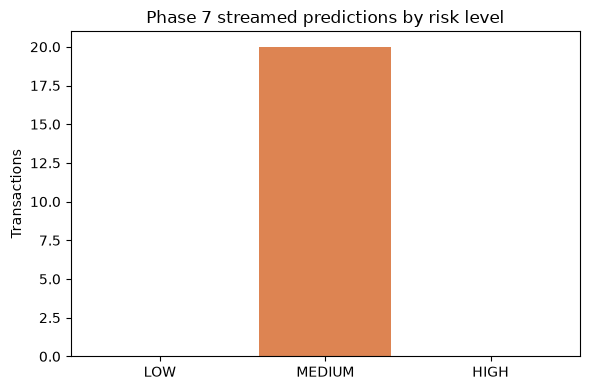

In [33]:
import json

import re

errors = len(re.findall(r"Traceback|Exception|FEATURE CONTRACT VIOLATION", _spark_text))



def _check_value(name):

    value = CHECKS.get(name)

    return value if isinstance(value, bool) else None



def _status(*values):

    if any(value is False for value in values):

        return "FAIL"

    if any(value is None for value in values):

        return "NOT TESTED"

    return "PASS"



feature_parity = globals().get("FEATURE_PARITY_DETAILS")

prediction_parity = globals().get("PRED_PARITY_DETAILS")

parity_path = PROJECT_ROOT / "reports" / "phase7_parity_summary.json"

if (feature_parity is None or prediction_parity is None) and parity_path.is_file():

    persisted_parity = json.loads(parity_path.read_text(encoding="utf-8"))

    feature_parity = persisted_parity.get("feature_parity")

    prediction_parity = persisted_parity.get("prediction_parity")

feature_parity_ok = isinstance(feature_parity, dict) and feature_parity.get("result") == "PASS"

prediction_parity_ok = isinstance(prediction_parity, dict) and prediction_parity.get("result") == "PASS"

if feature_parity is None:

    feature_parity_ok = None

if prediction_parity is None:

    prediction_parity_ok = None



contract_ok = _check_value("34-feature contract (checked per transaction inside process_batch; run aborts otherwise)")

model_version_ok = _check_value("Model version is V1 for every prediction")

persisted_ok = _check_value("Output persisted to CSV")

threshold_ok = _check_value("Existing threshold applied")

checkpoint_written_ok = _check_value("Checkpoint written (offsets/commits recorded)")

checkpoint_restart_ok = _check_value("Checkpoint restart does not reprocess old data")

schema_ok = _check_value("Streaming schema has no isFraud")

output_leakage_ok = _check_value("Prediction output has no isFraud column")

wire_leakage_ok = _check_value("Kafka payload contains no isFraud (inspected transport messages)")

real_kafka_used = TRANSPORT_USED == "kafka"

producer_ok = getattr(producer, "returncode", None) == 0

consumer_ok = getattr(consumer, "returncode", None) == 0 and len(preds) == NUM_TX

known_checks = [value for value in CHECKS.values() if value is not None]

all_checks_ok = bool(known_checks) and all(known_checks)



feature_status = _status(feature_parity_ok, contract_ok)

xgboost_status = _status(model_version_ok, prediction_parity_ok)

prediction_status = _status(persisted_ok, threshold_ok)

checkpoint_status = _status(checkpoint_written_ok, checkpoint_restart_ok)

leakage_status = _status(schema_ok, output_leakage_ok, wire_leakage_ok)

if wire_leakage_ok is None and leakage_status == "PASS":

    leakage_status = "NOT TESTED"

kafka_status = ("PASS" if real_kafka_used and BROKER_REACHABLE and CONNECTOR_OK and producer_ok else

                "NOT TESTED" if not real_kafka_used else "FAIL")

if not real_kafka_used or feature_status == "NOT TESTED" or xgboost_status == "NOT TESTED":

    end_to_end_status = "NOT TESTED"

elif real_kafka_used and consumer_ok and all_checks_ok and feature_status == "PASS" and xgboost_status == "PASS":

    end_to_end_status = "PASS"

else:

    end_to_end_status = "FAIL"



status = {

    "Kafka (real broker)": kafka_status,

    "Kafka topic": "PASS" if real_kafka_used and BROKER_REACHABLE else ("NOT TESTED" if not real_kafka_used else "FAIL"),

    "Kafka producer - message construction (no isFraud, chronological)": "PASS" if _check_value(">= 20 transactions processed") else "FAIL",

    "Kafka producer - delivery over the Kafka wire protocol": kafka_status,

    "Spark Structured Streaming": "PASS" if consumer_ok else "FAIL",

    "JSON parsing (explicit schema)": "PASS" if len(preds) == NUM_TX else "FAIL",

    "Feature engineering (reused Phase 5 code, 34-feature contract)": feature_status,

    "XGBoost V1 integration": xgboost_status,

    "Prediction output": prediction_status,

    "Checkpointing": checkpoint_status,

    "Ground-truth leakage check": leakage_status,

    "End-to-end streaming (real Kafka -> Spark -> Model V1)": end_to_end_status,

    f"End-to-end streaming ({TRANSPORT_USED} transport -> Spark -> Model V1)": end_to_end_status,

}

print("PHASE 7 STATUS")

for k, v in status.items():

    print(f"  {k:<66} {v}")



raw_rows = globals().get("RAW_ROWS")

summary = {

    "phase": "Phase 7 - Kafka + Spark Structured Streaming", "topic": config.KAFKA_TOPIC,

    "raw_dataset_rows": raw_rows, "raw_dataset_looks_like_full_paysim": raw_rows is not None and raw_rows > 6_000_000,

    "data_source_note": ("Results come from the raw CSV present when this notebook ran. Real PaySim has ~6.36M rows; if raw_dataset_rows is far "

                         "smaller, the CSV was a synthetic PaySim-shaped stand-in and these numbers are not claims about real data. Re-run locally to regenerate."),

    "transport_used": TRANSPORT_USED,

    "real_kafka_broker_available_in_this_run": bool(BROKER_REACHABLE), "spark_kafka_connector_available_in_this_run": bool(CONNECTOR_OK),

    "transactions_streamed": NUM_TX, "predictions_generated": int(len(preds)), "errors_detected_in_spark_log": errors,

    "model_version": api_app.MODEL_VERSION, "feature_count": len(api_app.FINAL_FEATURES), "classification_threshold": api_app.CLASSIFICATION_THRESHOLD,

    "risk_level_counts": preds["risk_level"].value_counts().to_dict(), "predicted_fraud_count": int(preds["predicted_label"].sum()),

    "fraud_probability_distinct_values": int(preds["fraud_probability"].nunique()),

    "checks": {k: ("NOT TESTED" if v is None else ("PASS" if v else "FAIL")) for k, v in CHECKS.items()},

    "feature_parity": feature_parity if feature_parity is not None else {"result": "NOT TESTED"},

    "prediction_parity": prediction_parity if prediction_parity is not None else {"result": "NOT TESTED"},

    "latency_seconds_local_bridge": globals().get("LATENCY"),

    "model_hashes_before": HASHES_BEFORE, "model_hashes_after": HASHES_AFTER, "model_unchanged": MODEL_UNCHANGED,

    "status": status,

}

config.SUMMARY_PATH.write_text(json.dumps(summary, indent=2, default=str))

print("\nSaved ->", config.SUMMARY_PATH)



fig, ax = plt.subplots(figsize=(6, 4))

lv = preds["risk_level"].value_counts().reindex(["LOW", "MEDIUM", "HIGH"], fill_value=0)

ax.bar(lv.index, lv.values, color=["#55A868", "#DD8452", "#C44E52"])

ax.set(title="Phase 7 streamed predictions by risk level", ylabel="Transactions")

plt.tight_layout(); fig.savefig(PROJECT_ROOT / "reports/figures/streaming_risk_distribution.png", bbox_inches="tight"); plt.show()

## SECTION 16 — Troubleshooting & Exact Commands

**Three terminals (Windows / PowerShell), run from the project root `fraud-detection-system\`:**
```powershell
# Terminal 1 - Kafka (KRaft): see Section 4 for the one-time storage format, then:
.\bin\windows\kafka-server-start.bat .\config\kraft\server.properties
# (once) create the topic:
.\bin\windows\kafka-topics.bat --create --topic fraud-transactions --bootstrap-server 127.0.0.1:9092 --partitions 1 --replication-factor 1

# Terminal 2 - Spark Structured Streaming consumer
$env:PYSPARK_SUBMIT_ARGS = "--packages org.apache.spark:spark-sql-kafka-0-10_2.13:4.2.0 pyspark-shell"   # match `pyspark --version`
python -m src.streaming.spark_streaming --mode kafka

# Terminal 3 - Producer (start after Terminal 2 is running)
python -m src.streaming.kafka_producer --num-transactions 20 --delay 0.5 --mode kafka
```
Then re-run this notebook (it will pick up Kafka automatically if both broker and connector are available).

| Symptom | Likely cause / fix |
|---|---|
| `java: command not found` | Install JDK 11+ and add it to `PATH`; restart the terminal. |
| `Failed to find data source: kafka` | Connector jar missing: set `PYSPARK_SUBMIT_ARGS` as above (Maven Central must be reachable). |
| Producer prints "no Kafka broker reachable ... local bridge" | Broker not running / wrong `KAFKA_BOOTSTRAP_SERVERS` in `config.py`. |
| `FileNotFoundError: Raw PaySim CSV` | Place the CSV in `data/raw/` (git-ignored by design). |
| Nothing processed after a restart | Expected: the checkpoint remembers what was consumed. Delete `checkpoints/` to reprocess from the start. |
| `FEATURE CONTRACT VIOLATION` | Stop: model/feature artifacts are out of sync. Do **not** edit Model V1; re-check Phase 3/4 outputs. |

## SECTION 17 — Phase 7 Conclusion

Model V1 — byte-identical to the committed artifact — now runs behind a Spark Structured Streaming job that reuses the existing Phase 3/5 feature and past-only state logic unchanged, honours the 34-feature contract on every transaction, applies the existing threshold/risk semantics, keeps `isFraud` entirely out of the prediction path, persists its predictions, and resumes cleanly from a checkpoint. **What remains unverified is the live Kafka hop** (broker + connector), which needs a machine where they can be installed (Section 16); the result table in Section 15 marks it NOT TESTED rather than PASS when that is the case. Phase 8 (XAI) is intentionally not started.